### Explore the data generated by the random games

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from dungeongame.model import Agent
from dungeongame import DungeonGame

In [ ]:
GAMESTATE_COLUMN_ORDER = ['rounds', 'phase_rounds', 'defeats',
       'points', 'deck_size', 'dungeon_size', 'adventurer_hp', 'has_armor',
       'has_shield', 'has_chalice', 'has_torch', 'has_vorpal', 'has_lance',
       'drew_goblin', 'drew_skeleton', 'drew_orc', 'drew_vampire',
       'drew_golem', 'drew_wraith', 'drew_demon', 'drew_dragon',
       'Goblin_taken', 'Skeleton_taken', 'Orc_taken', 'Vampire_taken',
       'Golem_taken', 'Wraith_taken', 'Demon_taken', 'Dragon_taken',
       'Goblin_added', 'Skeleton_added', 'Orc_added', 'Vampire_added',
       'Golem_added', 'Wraith_added', 'Demon_added', 'Dragon_added',
       'potential_damage', 'Armor_taken', 'Shield_taken', 'Chalice_taken',
       'Torch_taken', 'Vorpal Sword_taken', 'Lance_taken',
       'Opponent_1_defeats', 'Opponent_1_points', 'Opponent_1_has_passed', 'Opponent_1_is_alive',
       'Opponent_1_Armor', 'Opponent_1_Shield', 'Opponent_1_Chalice',
       'Opponent_1_Torch', 'Opponent_1_Vorpal Sword', 'Opponent_1_Lance',
       'Opponent_2_defeats', 'Opponent_2_points', 'Opponent_2_has_passed', 'Opponent_2_is_alive',
       'Opponent_2_Armor', 'Opponent_2_Shield', 'Opponent_2_Chalice',
       'Opponent_2_Torch', 'Opponent_2_Vorpal Sword', 'Opponent_2_Lance',
       'Opponent_3_defeats', 'Opponent_3_points', 'Opponent_3_has_passed', 'Opponent_3_is_alive',
       'Opponent_3_Armor', 'Opponent_3_Shield', 'Opponent_3_Chalice',
       'Opponent_3_Torch', 'Opponent_3_Vorpal Sword', 'Opponent_3_Lance']

ACTION_SPACE_COLUMN_ORDER =  ['draw', 'pass',
       'remove_armor', 'remove_shield', 'remove_chalice', 'remove_torch',
       'remove_vorpal', 'remove_lance', 'add_to_dungeon', 'target_goblin',
       'target_skeleton', 'target_orc', 'target_vampire', 'target_golem',
       'target_wraith', 'target_demon', 'target_dragon']

EXCLUDE_COLS = ['game_id', 'current_player', 'card_drawn', 'reward']

In [8]:
# utility functions
def parse_log_entry(log):
    log = deepcopy(log)
    log[0].update(log[1])
    log[0].update(log[2])
    return log[0]

In [ ]:
def get_players(epsilon, mode="random"):
    players = [
    {
        "name": "Alan",
        "mode": mode,
        "epsilon": epsilon,
    },
    {
        "name": "Jane",
        "mode": mode,
        "epsilon": epsilon,
    },
    {
        "name": "Charlie",
        "mode": mode,
        "epsilon": epsilon,
    },
    {
        "name": "Georgia",
        "mode": mode,
        "epsilon": epsilon,
    }
    ]
    return players


def generate_training_data(epsilon, num_games, player_mode='random', agent=None):
    players = get_players(epsilon, player_mode)

    all_logs = []
    for count in range(num_games):
        count += 1
        game = DungeonGame(players=players, agent=agent, auto_run=True, log_game=True, verbose=False)
        game.run()
        logs = pd.DataFrame([parse_log_entry(log) for log in game.game_log])
        all_logs.append(logs)
    
    return pd.concat(all_logs).reset_index(drop=True)

In [2]:
# load game logs
game_logs = generate_training_data

In [3]:
# get all columns that are boolean
bool_cols = game_logs.select_dtypes(include=[bool]).columns

# convert boolean columns to int
game_logs[bool_cols] = game_logs[bool_cols].astype(int)

# get all columns that are objects
obj_cols = game_logs.select_dtypes(include=[object]).columns

In [4]:
game_logs.head()

,game_lengths,total_points_per_game,phase_round_when_players_pass,number_of_times_players_added_to_dungeon,total_rewards_per_game,policy_loss,value_loss
0,28.0,3.0,2.117647,7.0,100.0,-0.195771,46.716759
1,18.0,1.0,2.176471,7.0,300.0,-0.589135,41.134666
2,27.0,2.0,2.555556,6.0,400.0,-1.075517,50.817478
3,25.0,1.0,2.687500,11.0,300.0,-1.366148,51.443974
4,21.0,3.0,2.277778,5.0,-300.0,-0.668472,45.401344


In [5]:
# get all columns that are numeric
num_cols = game_logs.select_dtypes(include=[np.number]).columns

# drop non-numerical columns
game_logs = game_logs[num_cols]

In [6]:
# check which columns have missing values
missing = game_logs.isnull().sum()
missing = missing[missing > 0]
missing

Series([], dtype: int64)

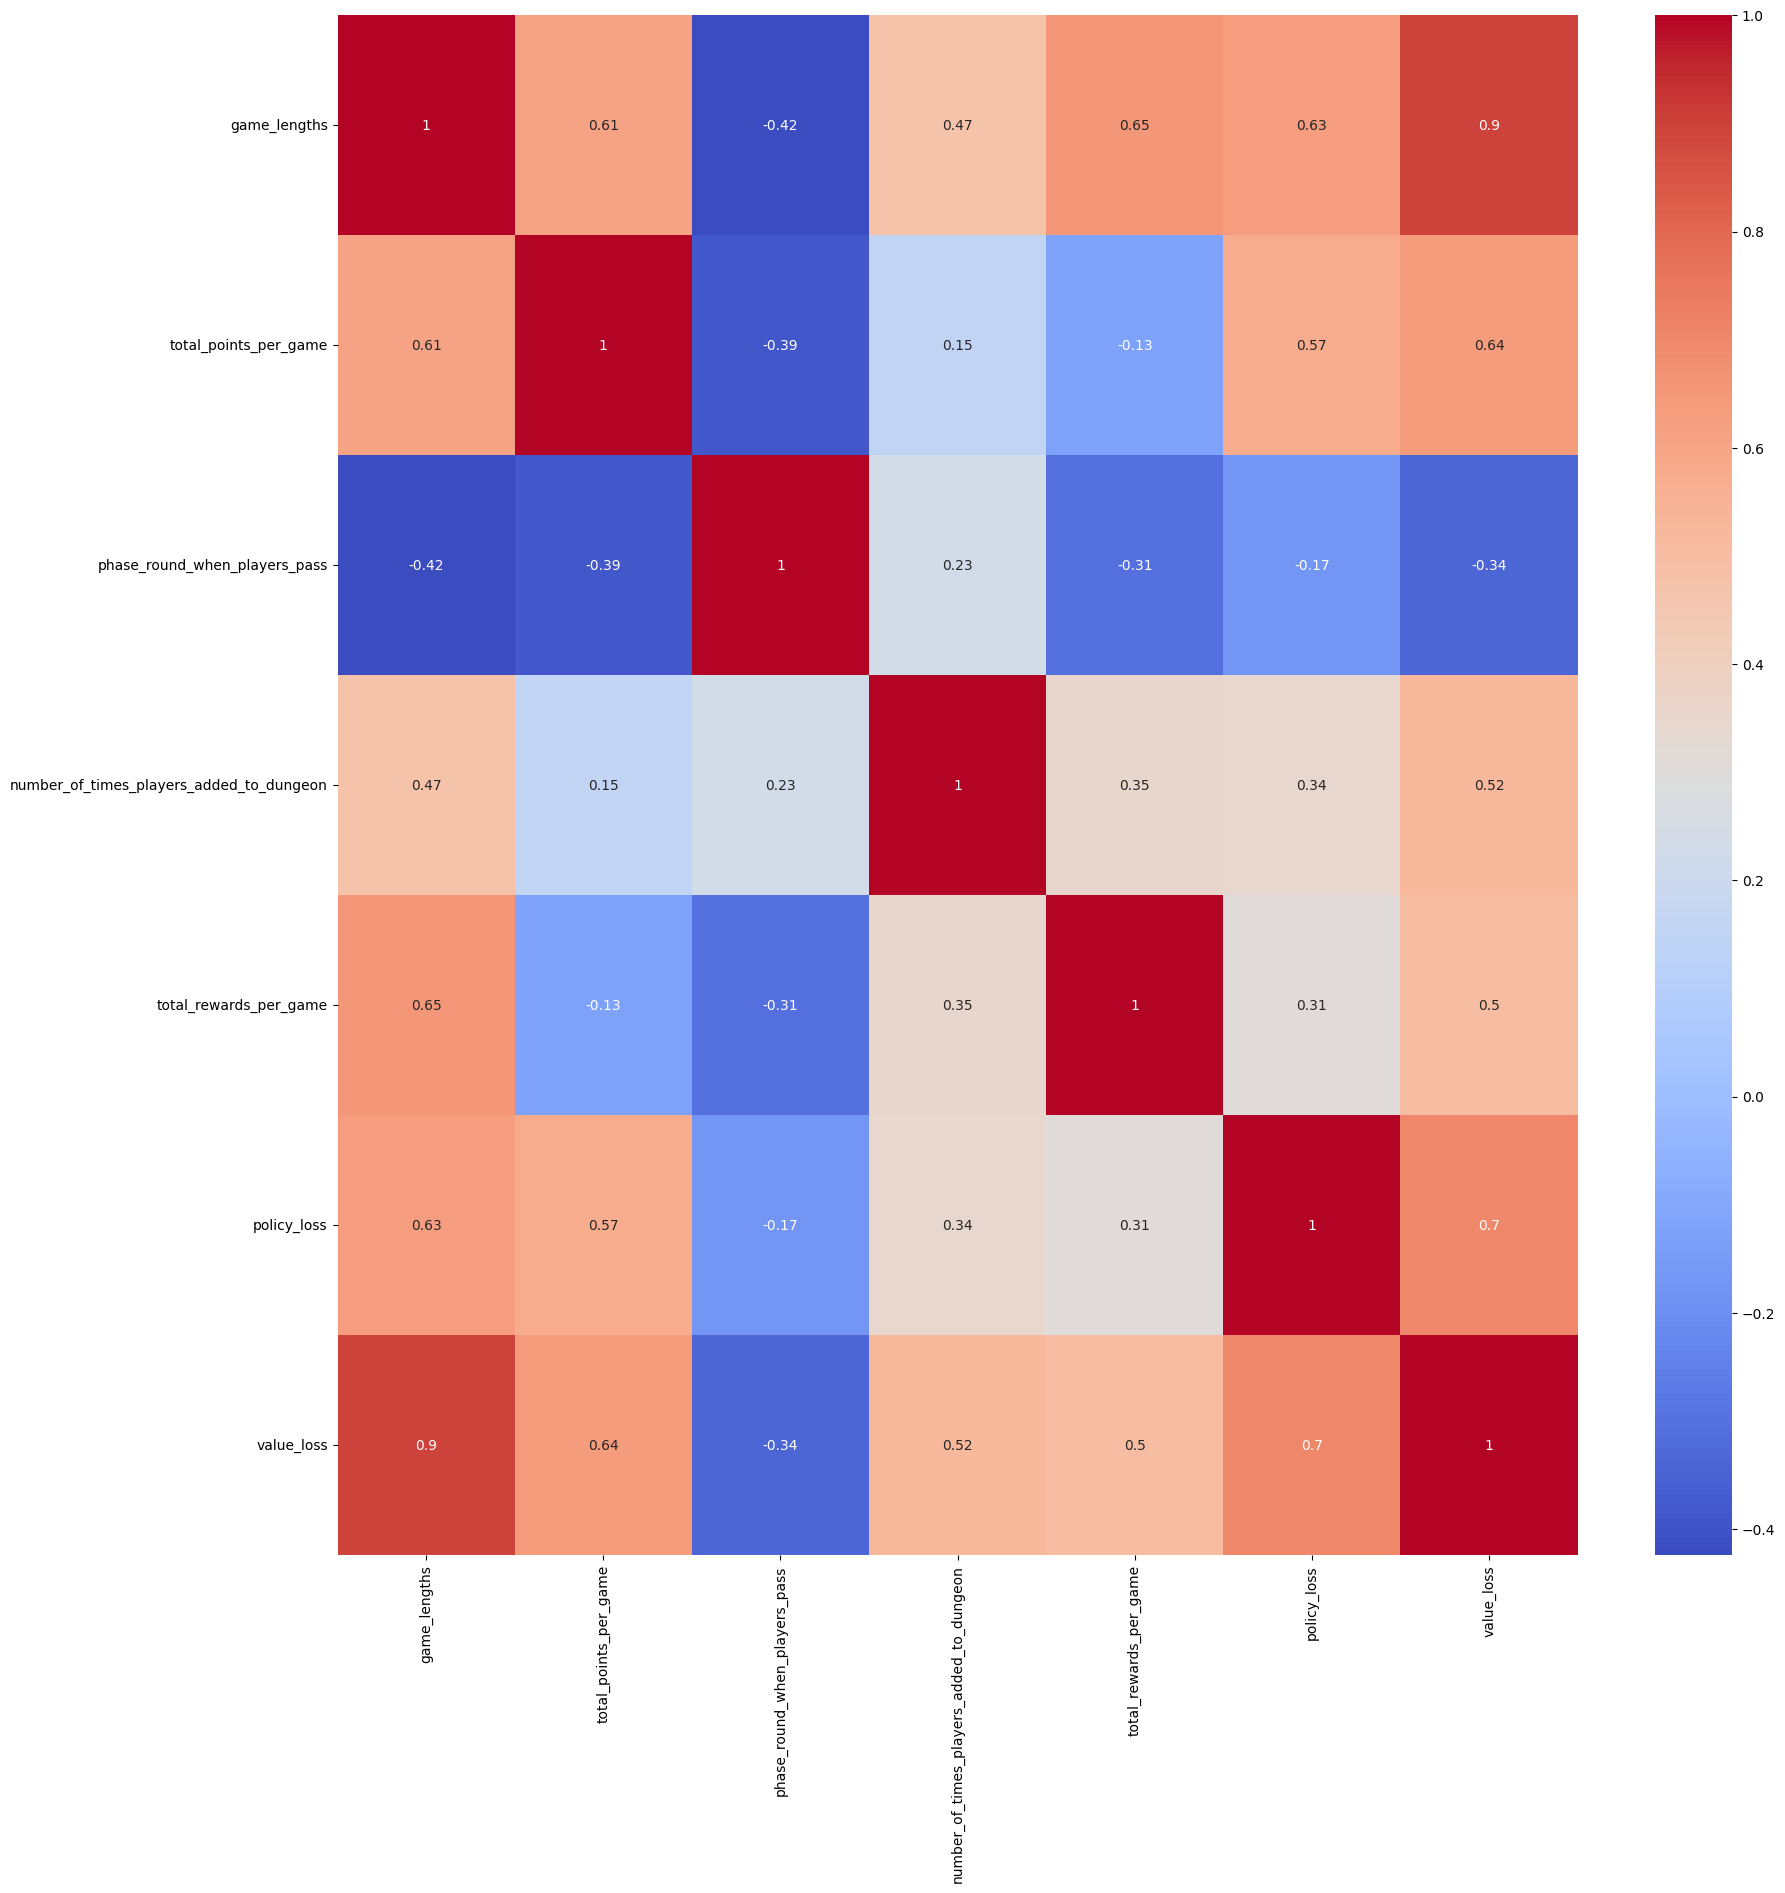

In [7]:
# the model was able to predict the reward for each stage of the game without any issues
# maybe there's a game variable that is causing the issue
# let's find the correlation between the reward and the game variables
correlation = game_logs.corr()

# plot the correlation
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()